In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving online_shoppers_intention.csv to online_shoppers_intention.csv


In [ ]:
df = pd.read_csv("online_shoppers_intention.csv")

In [ ]:
print(df.head())
print(df.info())

   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0         0.0   Feb   

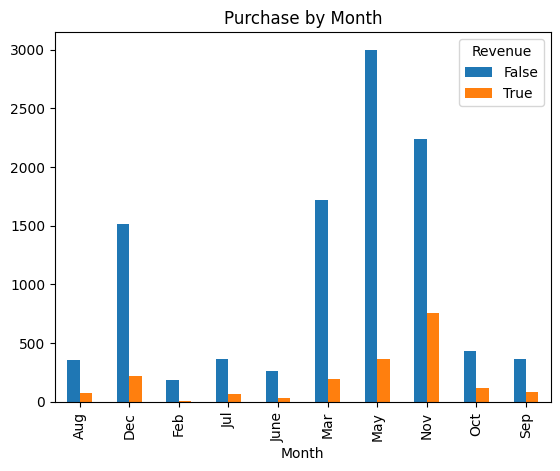

In [ ]:
# Purchase by Month
pd.crosstab(df['Month'], df['Revenue']).plot(kind='bar')
plt.title("Purchase by Month")
plt.show()

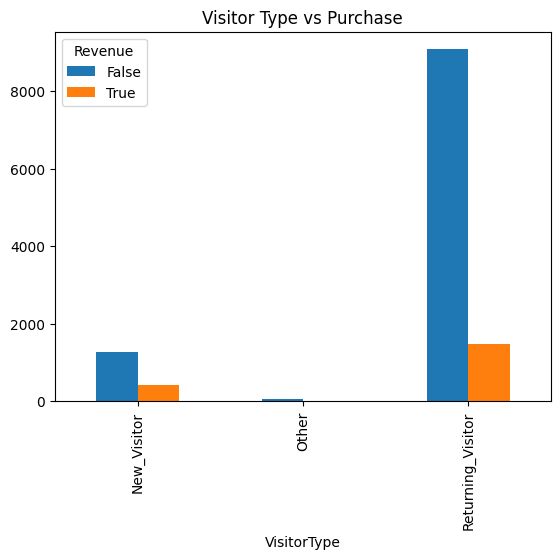

In [ ]:
# Purchase by Visitor Type
pd.crosstab(df['VisitorType'], df['Revenue']).plot(kind='bar')
plt.title("Visitor Type vs Purchase")
plt.show()

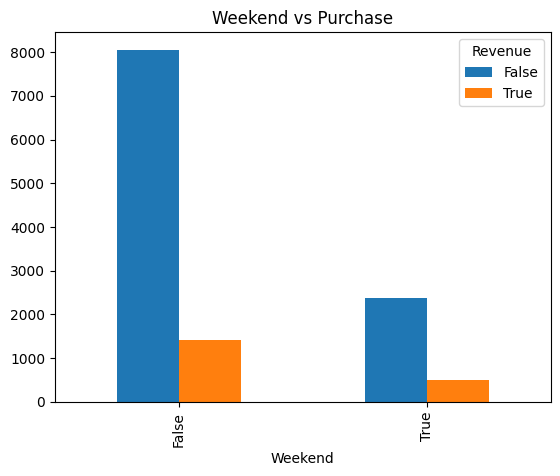

In [ ]:
# Weekend vs Purchase
pd.crosstab(df['Weekend'], df['Revenue']).plot(kind='bar')
plt.title("Weekend vs Purchase")
plt.show()

In [ ]:
# Encode categorical columns
le = LabelEncoder()
df['VisitorType'] = le.fit_transform(df['VisitorType'])
df['Month'] = le.fit_transform(df['Month'])

In [ ]:
# Select features
X = df[['PageValues', 'BounceRates', 'ExitRates',
        'ProductRelated_Duration', 'SpecialDay']]

y = df['Revenue'].astype(int)

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#logistic regression model
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [ ]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
#Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[1859  196]
 [ 116  295]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2055
           1       0.60      0.72      0.65       411

    accuracy                           0.87      2466
   macro avg       0.77      0.81      0.79      2466
weighted avg       0.88      0.87      0.88      2466



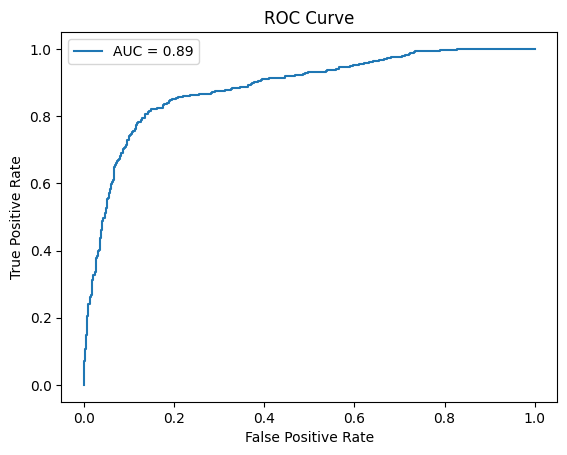

In [ ]:
#Roc curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


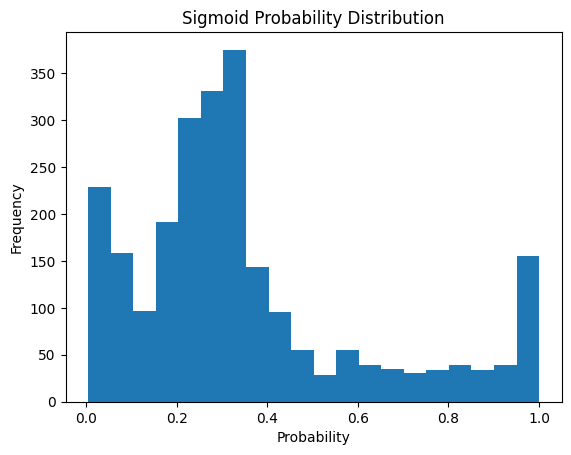

In [ ]:
#Sigmoid function
plt.hist(y_prob, bins=20)
plt.title("Sigmoid Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#coefficient analysis
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

In [ ]:
print("\nFeature Importance:")
print(coefficients)


Feature Importance:
                   Feature  Coefficient
0               PageValues     2.088869
1              BounceRates    -0.000727
2                ExitRates    -0.724831
3  ProductRelated_Duration     0.346140
4               SpecialDay    -0.313680


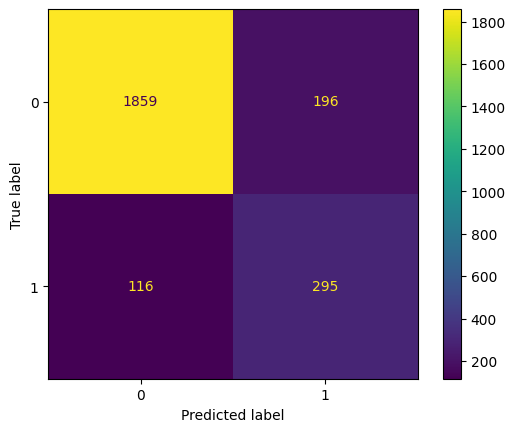

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

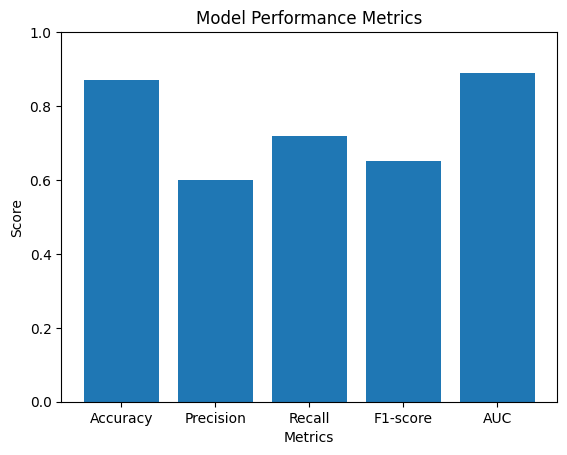

In [ ]:
#values
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']
values = [0.87, 0.60, 0.72, 0.65, 0.89]
plt.bar(metrics, values)
plt.title("Model Performance Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()